# Stacking and Blending (2/2) — Blending and K-fold Stacking by Hand

`StackingClassifier` hides an important trick: the meta-model must learn from predictions on data the base models
**did not train on**. In this notebook we build everything ourselves and watch what goes wrong when we ignore that rule.

**In this notebook**
1. Setup: data, split, base models
2. Naive stacking — the leakage trap
3. Blending by hand (hold-out set)
4. K-fold stacking by hand (out-of-fold predictions)
5. Check: our K-fold stacking = sklearn's `StackingClassifier`
6. One split is noisy → repeat over 20 random splits
7. Summary table

> 📖 Theory: [`theory.md`](theory.md) §2–§5, §9, §11 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, log_loss

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Setup: data, split, base models

Same data and base models as notebook 01. We keep a **test set (20 %) that nothing touches until the very end**.
`stratify=y` keeps the disease / no-disease ratio the same in every part.

In [2]:
df = pd.read_csv('heart.csv')
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8, stratify=y)
print('train:', X_train.shape, ' test:', X_test.shape)

base_models = {
    'rf':   RandomForestClassifier(n_estimators=100, random_state=42),
    'knn':  make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10)),
    'gbdt': GradientBoostingClassifier(random_state=42),
}

train: (242, 13)  test: (61, 13)


A small helper: given fitted base models, build the **meta-feature table** `Z` — one column per base model,
containing P(disease). This is exactly the table the meta-model learns from (theory §1).

> ✍️ **Core code: learn this.** Meta-features = the base models' predicted probabilities, one column per model.

In [3]:
def meta_features(fitted_models, X):
    return pd.DataFrame({name: m.predict_proba(X)[:, 1] for name, m in fitted_models.items()}, index=X.index)

# reference: each base model alone, trained on the full training set
fitted_full = {name: clone(m).fit(X_train, y_train) for name, m in base_models.items()}
single_test = {name: accuracy_score(y_test, m.predict(X_test)) for name, m in fitted_full.items()}
pd.Series(single_test, name='test accuracy').round(3)

rf      0.902
knn     0.836
gbdt    0.852
Name: test accuracy, dtype: float64

On this particular split Random Forest alone scores 0.902, KNN 0.836 and Gradient Boosting 0.852. Keep these in
mind: on this one split, **no stack below beats Random Forest alone**. §6 shows why one split is not enough to judge.

## 2. Naive stacking — the leakage trap

The "obvious" recipe (theory §2):
1. fit base models on the training set,
2. let them predict **the same training set**,
3. fit the meta-model on those predictions.

> ✍️ **Core code: learn this.** This is the WRONG way. Learn it so you can recognise it.

In [4]:
Z_train_naive = meta_features(fitted_full, X_train)   # in-sample predictions  ← leakage!
Z_test        = meta_features(fitted_full, X_test)

meta_naive = LogisticRegression(max_iter=1000).fit(Z_train_naive, y_train)

print('meta-model coefficients:', pd.Series(meta_naive.coef_[0], index=Z_train_naive.columns).round(2).to_dict())
print('train accuracy:', round(meta_naive.score(Z_train_naive, y_train), 3))
print('test accuracy: ', round(meta_naive.score(Z_test, y_test), 3))

meta-model coefficients: {'rf': 3.79, 'knn': 0.7, 'gbdt': 3.86}
train accuracy: 1.0
test accuracy:  0.852


**Training accuracy 1.0 — perfect! Test accuracy only 0.852.** The meta-model looks flawless on the data it
learned from, but that does not carry over to new patients.

Look at the weights: the naive meta-model trusts **Random Forest (3.79) and Gradient Boosting (3.86)** heavily and
almost ignores **KNN (0.70)**. Trees can (almost) memorise their training rows, so their in-sample probabilities are
nearly perfect; KNN (k = 10) cannot memorise, so it looks "worse". The meta-model learned a false story.

Why does this happen? Compare the Random Forest's probabilities for **training rows it has seen** (in-sample)
with probabilities for the same rows when it has **not** seen them (out-of-fold, explained in §4):

In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_oof = cross_val_predict(clone(base_models['rf']), X_train, y_train, cv=cv5, method='predict_proba')[:, 1]

print('Random Forest accuracy on training rows')
print('  in-sample   :', round(accuracy_score(y_train, Z_train_naive['rf'] > 0.5), 3))
print('  out-of-fold :', round(accuracy_score(y_train, rf_oof > 0.5), 3))

Random Forest accuracy on training rows
  in-sample   : 1.0
  out-of-fold : 0.81


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

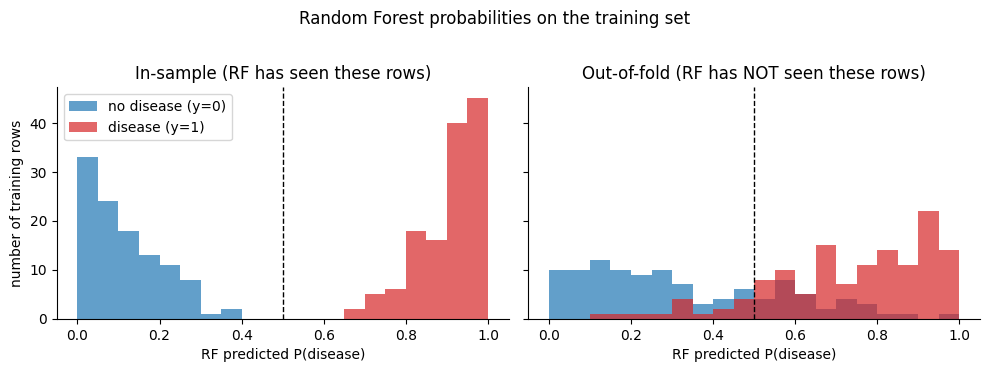

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
bins = np.linspace(0, 1, 21)
for ax, p, title in [(axes[0], Z_train_naive['rf'].values, 'In-sample (RF has seen these rows)'),
                     (axes[1], rf_oof, 'Out-of-fold (RF has NOT seen these rows)')]:
    ax.hist(p[y_train.values == 0], bins=bins, alpha=0.7, label='no disease (y=0)', color='tab:blue')
    ax.hist(p[y_train.values == 1], bins=bins, alpha=0.7, label='disease (y=1)', color='tab:red')
    ax.axvline(0.5, color='k', ls='--', lw=1)
    ax.set_title(title); ax.set_xlabel('RF predicted P(disease)')
axes[0].set_ylabel('number of training rows'); axes[0].legend()
plt.suptitle('Random Forest probabilities on the training set', y=1.02)
plt.tight_layout(); plt.show()

- **Left (in-sample):** the two classes are perfectly separated — RF gets 100 % of its own training rows right.
- **Right (out-of-fold):** the honest picture — the classes overlap and RF gets only 81 % right.

A meta-model trained on the left picture believes "RF is never wrong". That is the leakage (theory §2).

## 3. Blending by hand (hold-out set)

Fix 1 (theory §3): split the **training** data once more. Base models learn on `D_train` (75 %); the meta-model learns
on their predictions for the hold-out part `D_hold` (25 %), which the base models never saw. The test set is still
untouched.

> ✍️ **Core code: learn this.** Blending: base models on D_train → predictions on D_hold → meta-model.

In [7]:
X_tr, X_hold, y_tr, y_hold = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
print('D_train:', X_tr.shape, ' D_hold:', X_hold.shape)

# step 1: base models learn on D_train only
fitted_blend = {name: clone(m).fit(X_tr, y_tr) for name, m in base_models.items()}

# step 2: their predictions on D_hold become the meta-model's training data
Z_hold = meta_features(fitted_blend, X_hold)
meta_blend = LogisticRegression(max_iter=1000).fit(Z_hold, y_hold)

# step 3: predict the test set: base models -> meta-model
Z_test_blend = meta_features(fitted_blend, X_test)
blend_acc = meta_blend.score(Z_test_blend, y_test)
print('meta-model coefficients:', pd.Series(meta_blend.coef_[0], index=Z_hold.columns).round(2).to_dict())
print('blending test accuracy:', round(blend_acc, 3))

D_train: (181, 13)  D_hold: (61, 13)


meta-model coefficients: {'rf': 1.12, 'knn': 1.0, 'gbdt': 0.88}
blending test accuracy: 0.869


The blending meta-model gives **similar weights to all three models** (RF 1.12, KNN 1.00, GBDT 0.88) — no more
blind trust in the trees. Test accuracy on this split: **0.869**.

Notice the cost: the base models were trained on only 181 rows instead of 242, and the meta-model learned from only
61 hold-out rows (theory §3).

## 4. K-fold stacking by hand (out-of-fold predictions)

Fix 2 (theory §4): use 5-fold cross-validation so **every** training row gets a prediction from a model that did not
see it. `cross_val_predict` does exactly that. Then refit each base model on the **full** training set for predicting
new data.

> ✍️ **Core code: learn this.** K-fold stacking: OOF predictions (cross_val_predict) → meta-model; refit base models on all training data.

In [8]:
# step 1: out-of-fold probabilities for every training row, one column per base model
Z_train_oof = pd.DataFrame({
    name: cross_val_predict(clone(m), X_train, y_train, cv=cv5, method='predict_proba')[:, 1]
    for name, m in base_models.items()
}, index=X_train.index)

# step 2: meta-model learns from the honest OOF predictions
meta_oof = LogisticRegression(max_iter=1000).fit(Z_train_oof, y_train)

# step 3: base models refitted on the FULL training set (already done above: fitted_full) -> test meta-features
Z_test = meta_features(fitted_full, X_test)
kfold_acc = meta_oof.score(Z_test, y_test)

print('meta-model coefficients:', pd.Series(meta_oof.coef_[0], index=Z_train_oof.columns).round(2).to_dict())
print('train accuracy (on OOF features):', round(meta_oof.score(Z_train_oof, y_train), 3))
print('K-fold stacking test accuracy:  ', round(kfold_acc, 3))

meta-model coefficients: {'rf': 2.14, 'knn': 2.45, 'gbdt': 0.92}
train accuracy (on OOF features): 0.806
K-fold stacking test accuracy:   0.852


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

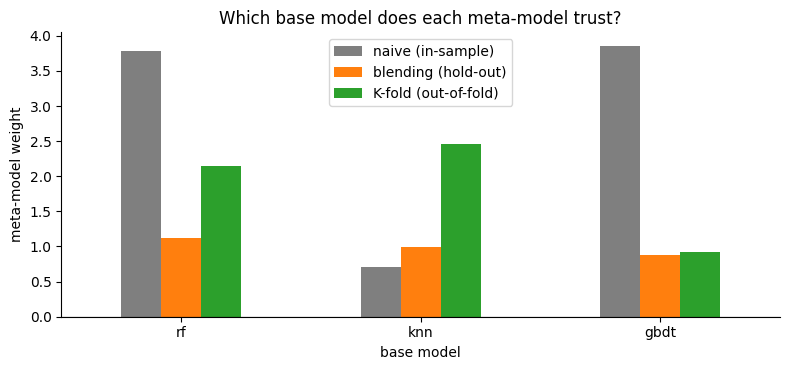

In [9]:
coef_df = pd.DataFrame({'naive (in-sample)': meta_naive.coef_[0],
                        'blending (hold-out)': meta_blend.coef_[0],
                        'K-fold (out-of-fold)': meta_oof.coef_[0]}, index=list(base_models))
ax = coef_df.plot.bar(figsize=(8, 3.8), rot=0, color=['tab:gray', 'tab:orange', 'tab:green'])
ax.set_ylabel('meta-model weight'); ax.set_xlabel('base model')
ax.set_title('Which base model does each meta-model trust?')
ax.axhline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

- The training accuracy is now an honest **0.806** (not 1.0), because the meta-model sees realistic predictions.
- The weights now say **KNN (2.45) ≥ RF (2.14) ≫ GBDT (0.92)** — the opposite of the naive story where KNN was nearly
  ignored. This matches notebook 01, where KNN and RF were the stronger base models and GBDT the weakest.
- Test accuracy on this split: **0.852** — the *same* as naive stacking on this split. With only 61 test rows, one
  split cannot show the difference between the methods. §6 fixes that.

In the bar chart: grey (naive) shows the inflated trust in the trees, green (K-fold) is the honest version, orange
(blending) is honest too but noisier because it learned from only 61 hold-out rows.

## 5. Check: our K-fold stacking = sklearn's `StackingClassifier`

If we give `StackingClassifier` the same base models, the same meta-model and **the same CV splitter**, it should do
exactly what we did by hand.

In [10]:
sk_stack = StackingClassifier(estimators=[(n, clone(m)) for n, m in base_models.items()],
                              final_estimator=LogisticRegression(max_iter=1000), cv=cv5)
sk_stack.fit(X_train, y_train)

print('sklearn meta-model coefficients:', sk_stack.final_estimator_.coef_[0].round(2))
print('sklearn test accuracy:', round(sk_stack.score(X_test, y_test), 3))
print('same probabilities as our version?', np.allclose(sk_stack.predict_proba(X_test), meta_oof.predict_proba(Z_test)))

sklearn meta-model coefficients: [2.14 2.45 0.92]
sklearn test accuracy: 0.852
same probabilities as our version? True


✅ Identical coefficients (2.14, 2.45, 0.92), identical test accuracy (0.852), identical probabilities.
So **`StackingClassifier(cv=5)` is exactly K-fold stacking**: out-of-fold predictions for the meta-model, base models
refitted on the full training set for prediction. (sklearn uses `predict_proba` and keeps one column per base model
for a binary problem, just like our helper.)

## 6. One split is noisy → repeat over 20 random splits

The test set has only 61 patients, so one lucky or unlucky patient changes accuracy by 1.6 %. To compare the three
recipes fairly we repeat the whole procedure on **20 different train/test splits** and average. We also report
**log-loss** (lower = better), which punishes confident wrong probabilities, the typical symptom of a leaky meta-model.

In [11]:
def run_all(seed):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    full = {n: clone(m).fit(Xtr, ytr) for n, m in base_models.items()}
    Zte = meta_features(full, Xte)
    out = {}
    # naive
    meta = LogisticRegression(max_iter=1000).fit(meta_features(full, Xtr), ytr)
    out['naive: train acc'] = meta.score(meta_features(full, Xtr), ytr)
    out['naive: test acc'] = meta.score(Zte, yte)
    out['naive: test log-loss'] = log_loss(yte, meta.predict_proba(Zte))
    # K-fold stacking
    Zoof = pd.DataFrame({n: cross_val_predict(clone(m), Xtr, ytr, cv=cv, method='predict_proba')[:, 1]
                         for n, m in base_models.items()}, index=Xtr.index)
    meta = LogisticRegression(max_iter=1000).fit(Zoof, ytr)
    out['K-fold: train acc'] = meta.score(Zoof, ytr)
    out['K-fold: test acc'] = meta.score(Zte, yte)
    out['K-fold: test log-loss'] = log_loss(yte, meta.predict_proba(Zte))
    # blending
    Xa, Xh, ya, yh = train_test_split(Xtr, ytr, test_size=0.25, random_state=42, stratify=ytr)
    part = {n: clone(m).fit(Xa, ya) for n, m in base_models.items()}
    meta = LogisticRegression(max_iter=1000).fit(meta_features(part, Xh), yh)
    out['blending: test acc'] = meta.score(meta_features(part, Xte), yte)
    out['blending: test log-loss'] = log_loss(yte, meta.predict_proba(meta_features(part, Xte)))
    # single base models
    for n, m in full.items():
        out[f'{n} alone: test acc'] = m.score(Xte, yte)
    return out

repeats = pd.DataFrame([run_all(seed) for seed in range(20)])
summary = repeats.agg(['mean', 'std']).T.round(3)
summary

,mean,std
naive: train acc,0.999,0.002
naive: test acc,0.820,0.047
naive: test log-loss,0.422,0.096
K-fold: train acc,0.822,0.013
K-fold: test acc,0.841,0.043
K-fold: test log-loss,0.379,0.054
blending: test acc,0.828,0.049
blending: test log-loss,0.412,0.043
rf alone: test acc,0.839,0.050
knn alone: test acc,0.841,0.038


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

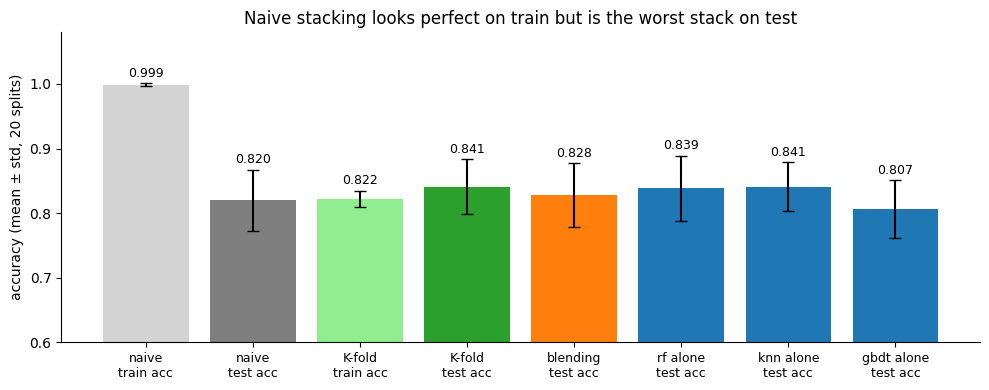

In [12]:
acc_cols = ['naive: train acc', 'naive: test acc', 'K-fold: train acc', 'K-fold: test acc', 'blending: test acc',
            'rf alone: test acc', 'knn alone: test acc', 'gbdt alone: test acc']
colors = ['lightgray', 'tab:gray', 'lightgreen', 'tab:green', 'tab:orange', 'tab:blue', 'tab:blue', 'tab:blue']
m, s = repeats[acc_cols].mean(), repeats[acc_cols].std()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(acc_cols)), m, yerr=s, color=colors, capsize=4)
for i, v in enumerate(m):
    ax.text(i, v + s.iloc[i] + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(range(len(acc_cols)))
ax.set_xticklabels([c.replace(': ', '\n') for c in acc_cols], fontsize=9)
ax.set_ylim(0.6, 1.08); ax.set_ylabel('accuracy (mean ± std, 20 splits)')
ax.set_title('Naive stacking looks perfect on train but is the worst stack on test')
plt.tight_layout(); plt.show()

Averaged over 20 random splits:

| recipe | train acc | test acc | test log-loss |
|---|---|---|---|
| naive stacking (leaky) | **0.999** | 0.820 | 0.422 |
| blending | — | 0.828 | 0.412 |
| K-fold stacking | 0.822 | **0.841** | **0.379** |

- **Naive stacking**: near-perfect training accuracy, but the **worst** test accuracy and log-loss of the three
  stacking recipes. The huge train/test gap (0.999 → 0.820) is the classic sign of leakage / overfitting.
- **K-fold stacking** is the best of the three, on both accuracy and log-loss, and its train and test scores are close
  (0.822 vs 0.841) — an honest model.
- **Blending** sits in between: no leakage, but it pays for throwing away 25 % of the training data.

Honest note: K-fold stacking (0.841) only **ties** the best single base model here (KNN alone 0.841, RF alone 0.839),
and all the standard deviations (~0.04–0.05) are larger than the gaps. On 303 rows, the clear lesson is *how to stack
correctly*, not that stacking wins.

## 7. Summary table

| method | how the meta-model's training data is made | base models trained on | mean test acc (20 splits) |
|---|---|---|---|
| Naive stacking ❌ | base models predict their **own** training rows | all training data | 0.820 |
| Blending | base models predict a **hold-out** part of the training data | 75 % of training data | 0.828 |
| K-fold stacking ✅ | **out-of-fold** predictions (`cross_val_predict`) | all training data (refit) | 0.841 |
| sklearn `StackingClassifier(cv=5)` | same as K-fold stacking (verified identical in §5) | all training data (refit) | = K-fold |
| best single model (KNN alone) | — | all training data | 0.841 |

## Key takeaways

- **Never** train the meta-model on in-sample predictions: on heart.csv the naive stack reached 0.999 train accuracy
  but the worst test accuracy (0.820) of the three recipes, and it trusted the trees for the wrong reason.
- **Blending** = meta-model trained on predictions for a hold-out set. Simple, leak-free, but wastes data (0.828).
- **K-fold stacking** = meta-model trained on out-of-fold predictions, then base models refitted on all data (0.841).
  This is exactly what `StackingClassifier(cv=K)` does — we reproduced its predictions exactly.
- Judge on many splits / cross-validation: on a single 61-row test split, naive and K-fold stacking even scored the same.
- On this small dataset the correct stack only ties the best single model. Use stacking when it measurably helps.

## 🧠 Quick check

<details><summary>Why is the naive meta-model's training accuracy (almost) 100 %?</summary>
It is trained on in-sample predictions. Random Forest and Gradient Boosting have (nearly) memorised the training rows,
so their probabilities there are almost perfect. The meta-model learns to copy them, which does not carry over to new
data.</details>

<details><summary>In blending, where does the meta-model's training data come from?</summary>
From the base models' predictions on a hold-out part of the <b>training</b> data (never the test set), which the
base models were not trained on.</details>

<details><summary>What does <code>cross_val_predict(..., method='predict_proba')</code> return?</summary>
For every training row, the predicted probabilities from the model trained on the other folds, i.e. out-of-fold
predictions.</details>

<details><summary>After computing OOF predictions, which base models are used to predict the test set?</summary>
Base models refitted on the full training set (sklearn stores them in <code>named_estimators_</code>).</details>

➡️ **Next:** this is the last notebook of the ensemble-learning folders. Revise the whole family with
[`theory.md`](theory.md) §9 (voting vs blending vs stacking) and [`../01-introduction/`](../01-introduction/).